# Gated DeltaNet for Linear Attention

Recently, [Qwen3-Next](https://qwen.ai/blog?id=4074cca80393150c248e508aa62983f9cb7d27cd&from=research.latest-advancements-list) and [Kimi Linear](https://arxiv.org/abs/2510.26692) proposed hybrid transformers that implement alternatives to the attention mechanism that scale linearly instead of quadratically with respect to the context length.

Both Qwen3-Next and Kimi Linear use a 3:1 ratio, meaning for every three transformer blocks employing the linear Gated DeltaNet variant, there’s one block that uses full attention, as shown in the figure below.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/bonus/gated_deltanet/01.webp" alt="Qwen3-Next versus Kimi Linear">



&nbsp;

## Introduction and Overview

Gated DeltaNet is a linear attention variant with inspiration from recurrent neural networks, including a gating mechanism from the [Gated Delta Networks: Improving Mamba2 with Delta Rule](https://arxiv.org/abs/2412.06464) paper. In a sense, Gated DeltaNet is a DeltaNet with Mamba-style gating, and DeltaNet is a linear attention mechanism.

Kimi Linear modifies the linear attention mechanism of Qwen3-Next by the Kimi Delta Attention (KDA) mechanism, which is essentially a refinement of Gated DeltaNet. Whereas Qwen3-Next applies a scalar gate (one value per attention head) to control the memory decay rate, Kimi Linear replaces it with a channel-wise gating for each feature dimension. According to the authors, this gives more control over the memory, and this, in turn, improves long-context reasoning.

In addition, for the full attention layers, Kimi Linear replaces Qwen3-Next’s gated attention layers (which are essentially standard multi-head attention layers with output gating) with Multi-Head Latent Attention (MLA). This is the same MLA mechanism we discussed earlier in the DeepSeek V3/R1 section, but with an additional gate. (To recap, MLA compresses the key/value space to reduce the KV cache size.)

The MLA in Kimi Linear does not use the gate, which was intentional so that the authors could compare the architecture more directly to standard MLA, however, they [stated](https://x.com/yzhang_cs/status/1984631714464088563) that they plan to add it in the future.

Since we already implemented MLA in [../05_mla](../05_mla), this bonus material focuses on the Gated DeltaNet aspect.


&nbsp;
## Gated Attention

Before we get to the Gated DeltaNet itself, let's briefly talk about the gate. As you can see in the upper part of the Qwen3-Next architecture in the previous figure, Qwen3-Next uses "gated attention". This is essentially regular full attention with an additional sigmoid gate.

This gating is a simple modification that I added to the `MultiHeadAttention`  code from chapter 3 below for illustration purposes:

```python
import torch
from torch import nn

class GatedMultiHeadAttention(nn.Module):
    def __init__(
        self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False
    ):
        super().__init__()
        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        ####################################################
        ### NEW: Add gate
        self.W_gate = nn.Linear(d_in, d_out, bias=qkv_bias)
        ####################################################
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1),
            persistent=False,
        )

    def forward(self, x):
        b, num_tokens, _ = x.shape
        queries = self.W_query(x)
        ####################################################
        ### NEW: Add gate
        gate = self.W_gate(x)
        ####################################################
        keys = self.W_key(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(
            mask_bool, torch.finfo(attn_scores.dtype).min
        )

        attn_weights = torch.softmax(
            attn_scores / (self.head_dim ** 0.5), dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context = (attn_weights @ values).transpose(1, 2)
        context = context.reshape(b, num_tokens, self.d_out)

        ####################################################
        ### NEW: Add gate
        context = context * torch.sigmoid(gate)
        ####################################################
        out = self.out_proj(context)
        return out
```



As we can see, after computing attention as usual, the model uses a separate gating signal from the same input, applies a sigmoid to keep it between 0 and 1, and multiplies it with the attention output. This allows the model to scale up or down certain features dynamically. The Qwen3-Next developers [state](https://qwen.ai/blog?id=4074cca80393150c248e508aa62983f9cb7d27cd&from=research.latest-advancements-list) that this helps with training stability:

> [...] the attention output gating mechanism helps eliminate issues like Attention Sink and Massive Activation, ensuring numerical stability across the model.


&nbsp;
## Gated DeltaNet

Now, what is Gated DeltaNet? Gated DeltaNet (short for *Gated Delta Network*) is Qwen3-Next's linear-attention layer, which is intended as an alternative to standard softmax attention. It was adopted from the [Gated Delta Networks: Improving Mamba2 with Delta Rule](https://arxiv.org/abs/2412.06464) paper as mentioned earlier.

Gated DeltaNet was originally proposed as an improved version of Mamba2, where it combines the gated decay mechanism of Mamba2 with a delta rule.

Mamba is a state-space model (an alternative to transformers), a big topic that deserves separate coverage in the future.

The delta rule part refers to computing the difference (delta, Δ) between new and predicted values to update a hidden state that is used as a memory state (more on that later).

(Side note: Readers with classic machine learning literature can think of this as similar to Hebbian learning inspired by biology: "Cells that fire together wire together." It's basically a precursor of the perceptron update rule and gradient descent-based learning, but without supervision.)

Gated DeltaNet has a gate similar to the gate in gated attention discussed earlier, except that it uses a SiLU instead of logistic sigmoid activation, as illustrated below. (The SiLU choice is likely to improve gradient flow and stability over the standard sigmoid.)

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/bonus/gated_deltanet/02.webp" alt="Gated DeltaNet" width=500px>

However, as shown in the figure above, the "gated" in the Gated DeltaNet also refers to several additional gates:

- `α` (decay gate) controls how fast the memory decays or resets over time,
- `β` (update gate) controls how strongly new inputs modify the state.

In code, a simplified version of the Gated DeltaNet depicted above (without the convolutional mixing) can be implemented as follows (the code is inspired by the [official implementation](https://github.com/huggingface/transformers/blob/0ed6d51ae8ed3f4fafca67a983b8d75bc76cd51b/src/transformers/models/qwen3_next/modular_qwen3_next.py#L835) by the Qwen3 team).

(Note that some implementations refer to the decay gate as `gk` (gate for step k), where `exp(gk)` matches the paper's $\alpha_t$. To keep this relationship explicit, the snippet below separates the log-space gate `alpha_log` from the exponentiated decay `alpha`.)


```python
import torch
from torch import nn
import torch.nn.functional as F

def l2norm(x, dim=-1, eps=1e-6):
    return x * torch.rsqrt((x * x).sum(dim=dim, keepdim=True) + eps)

class GatedDeltaNet(nn.Module):
    def __init__(
        self, d_in, d_out, dropout, num_heads, qkv_bias=False
    ):
        super().__init__()
        assert d_out % num_heads == 0

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        ####################################################
        ### NEW: Gates for delta rule and output gating
        self.W_gate = nn.Linear(d_in, d_out, bias=False)
        self.W_beta = nn.Linear(d_in, d_out, bias=False)

        # Note: The decay gate alpha corresponds to
        # A_log + W_alpha(x) + dt_bias
        self.W_alpha = nn.Linear(d_in, num_heads, bias=False)
        self.dt_bias = nn.Parameter(torch.ones(num_heads))
        A_init = torch.empty(num_heads).uniform_(0, 16)
        self.A_log = nn.Parameter(torch.log(A_init))
        # We could implement this as
        # W_alpha = nn.Linear(d_in, num_heads, bias=True)
        # but the bias is separate for interpretability and
        # to mimic the official implementation

        self.norm = nn.RMSNorm(self.head_dim, eps=1e-6)
        ####################################################

        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, num_tokens, _ = x.shape
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)
        ####################################################
        ### NEW: Compute delta rule gates
        beta = torch.sigmoid(self.W_beta(x))
        alpha_log = -self.A_log.exp().view(1, 1, -1) * F.softplus(
            self.W_alpha(x) + self.dt_bias
        )
        alpha = alpha_log.exp()
        gate = self.W_gate(x)
        ####################################################

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        beta = beta.view(b, num_tokens, self.num_heads, self.head_dim)
        gate = gate.view(b, num_tokens, self.num_heads, self.head_dim)  # NEW

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        beta = beta.transpose(1, 2)

        ####################################################
        ### NEW: QKNorm-like normalization for delta rule
        queries = l2norm(queries, dim=-1) / (self.head_dim ** 0.5)
        keys = l2norm(keys, dim=-1)
        ####################################################

        S = x.new_zeros(b, self.num_heads, self.head_dim, self.head_dim)

        outs = []
        ####################################################
        ### NEW: Gated delta rule update
        for t in range(num_tokens):
            k_t = keys[:, :, t]
            q_t = queries[:, :, t]
            v_t = values[:, :, t]
            b_t = beta[:, :, t]
            a_t = alpha[:, t].unsqueeze(-1).unsqueeze(-1)

            S = S * a_t
            kv_mem = (S * k_t.unsqueeze(-1)).sum(dim=-2)
            delta = (v_t - kv_mem) * b_t
            S = S + k_t.unsqueeze(-1) * delta.unsqueeze(-2)
            y_t = (S * q_t.unsqueeze(-1)).sum(dim=-2)
            ####################################################
            outs.append(y_t)

        context = torch.stack(outs, dim=2).transpose(1, 2).contiguous()
        context = context.view(b, num_tokens, self.num_heads, self.head_dim)

        ####################################################
        ### NEW: Apply RMSNorm and SiLU gate
        context = self.norm(context)
        context = context * F.silu(gate)
        ####################################################

        context = context.view(b, num_tokens, self.d_out)
        context = self.dropout(context)
        out = self.out_proj(context)
        return out
```

(Note that for simplicity, I omitted the convolutional mixing that Qwen3-Next and Kimi Linear use to keep the code more readable and focus on the recurrent aspects.)

So, as we can see above, there are lots of differences to standard (or gated) attention.

In gated attention, the model computes normal attention between all tokens (every token attends or looks at every other token). Then, after getting the attention output, a gate (a sigmoid) decides how much of that output to keep. The takeaway is that it's still the the regular scaled-dot product attention that scales quadratically with the context length.

As a refresher, scaled-dot production attention is computed as softmax(QKᵀ)V, where Q and K are *n*-by-*d* matrices, where *n* is the number of input tokens, and *d* is the embedding dimension. So QKᵀ results in an attention *n*-by-*n* matrix, that is multiplied by a *n*-by-*d* dimensional value matrix V:

```
attn_scores = queries @ keys.transpose(2, 3)

mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
attn_scores.masked_fill_(
    mask_bool, torch.finfo(attn_scores.dtype).min
)

attn_weights = torch.softmax(
    attn_scores / (self.head_dim ** 0.5), dim=-1
)

context = (attn_weights @ values).transpose(1, 2)
context = context.reshape(b, num_tokens, self.d_out)
```



<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/bonus/gated_deltanet/03.webp" alt="Quadratic attention" width=500px />

In Gated DeltaNet, there's no  *n*-by-*n* attention matrix. Instead, the model processes tokens one by one. It keeps a running memory (a state) that gets updated as each new token comes in. This is what's implemented as, where `S` is the state that gets updated recurrently for each time step *t*.

```python
S = x.new_zeros(b, self.num_heads, self.head_dim, self.head_dim)
outs = []

for t in range(num_tokens):
    k_t = keys[:, :, t]
    q_t = queries[:, :, t]
    v_t = values[:, :, t]
    b_t = beta[:, :, t]
    a_t = alpha[:, t].unsqueeze(-1).unsqueeze(-1)

    S = S * a_t
    kv_mem = (S * k_t.unsqueeze(-1)).sum(dim=-2)
    delta = (v_t - kv_mem) * b_t
    S = S + k_t.unsqueeze(-1) * delta.unsqueeze(-2)
    y_t = (S * q_t.unsqueeze(-1)).sum(dim=-2)
```

And the gates control how that memory changes:

- α (`alpha`) regulates how much of the old memory to forget (decay).

- β (`beta`) regulates how much the current token at time step *t* updates the memory.

(And the final output gate, not shown in the snippet above, is similar to gated attention; it controls how much of the output is kept.)

So, in a sense, this state update in Gated DeltaNet is similar to how recurrent neural networks (RNNs) work. The advantage is that it scales linearly (via the for-loop) instead of quadratically with context length.

The downside of this recurrent state update is that, compared to regular (or gated) attention, it sacrifices the global context modeling ability that comes from full pairwise attention.

Gated DeltaNet, can, to some extend, still capture context, but it has to go through the memory (*S*) bottleneck. That memory is a fixed size and thus more efficient, but it compresses past context into a single hidden state similar to RNNs.

That's why the Qwen3-Next and Kimi Linear architectures don't replace all attention layers with DeltaNet layers but use the 3:1 ratio mentioned earlier.

&nbsp;
## DeltaNet Memory Savings

In the previous section, we discussed the advantage of the DeltaNet over full attention in terms of linear instead of quadratic compute complexity with respect to the context length.

Next to the linear compute complexity, another big advantage of DeltaNet is the memory savings, as DeltaNet modules don't grow the KV cache. (For more information about KV caching, see [../03_kv-cache](../03_kv-cache)). Instead, as mentioned earlier, they keep a fixed-size recurrent state, so memory stays constant with context length.

For a regular multi-head attention (MHA) layer, we can compute the KV cache size as follows:

```
KV_cache_MHA ≈ batch_size × n_tokens × n_heads × d_head × 2 × bytes
```

(The 2 multiplier is there because we have both keys and values that we store in the cache.)

For the simplified DeltaNet version implemented above, we have:


```
KV_cache_DeltaNet = batch_size × n_heads × d_head × d_head × bytes
```

Note that the `KV_cache_DeltaNet` memory size doesn't have a context length (`n_tokens`) dependency. Also, we have only the memory state S that we store instead of separate keys and values, hence `2 × bytes` becomes just `bytes`. However, note that we now have a quadratic `d_head × d_head` in here. This comes from the state :

```
S = x.new_zeros(b, self.num_heads, self.head_dim, self.head_dim)
```

But that's usually nothing to worry about, as the head dimension is usually relatively small. For instance, it's 128 in Qwen3-Next.

The full version with the convolutional mixing is a bit more complex, including the kernel size and so on, but the formulas above should illustrate the main trend and motivation behind the Gated DeltaNet.

We can visualize the memory estimates and savings for different context lengths via the following helper script:

```bash
uv run plot_memory_estimates_gated_deltanet.py \
  --emb_dim 2048 \
  --n_heads 16 \
  --n_layers 48 \
  --dtype "bf16"
```

Note that the above computes the `head_dim` as `emb_dim / n_heads`. I.e., 2048 / 16  = 128.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/bonus/gated_deltanet/plot.webp" alt="Gated DeltaNet scaling" width=500px>

In [1]:
!git clone --depth 1 https://github.com/rasbt/LLMs-from-scratch.git

Cloning into 'LLMs-from-scratch'...
remote: Enumerating objects: 434, done.
remote: Counting objects: 100% (434/434), done.
remote: Compressing objects: 100% (320/320), done.
remote: Total 434 (delta 104), reused 423 (delta 101), pack-reused 0 (from 0)
Receiving objects: 100% (434/434), 2.24 MiB | 8.86 MiB/s, done.
Resolving deltas: 100% (104/104), done.


In [2]:
%cd /kaggle/working/LLMs-from-scratch/ch04/08_deltanet

/kaggle/working/LLMs-from-scratch/ch04/08_deltanet


In [3]:
!uv run plot_memory_estimates_gated_deltanet.py \
  --emb_dim 2048 \
  --n_heads 16 \
  --n_layers 48 \
  --dtype "bf16"

Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: /kaggle/working/LLMs-from-scratch/.venv
░░░░░░░░░░░░░░░░░░░░ [0/170] Installing wheels...                               warning: Failed to hardlink files; falling back to full copy. This may lead to degraded performance.
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 170 packages in 42.46s                            


In [5]:
!pip install pymupdf Pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 8.7 MB/s eta 0:00:00:00:0100:01


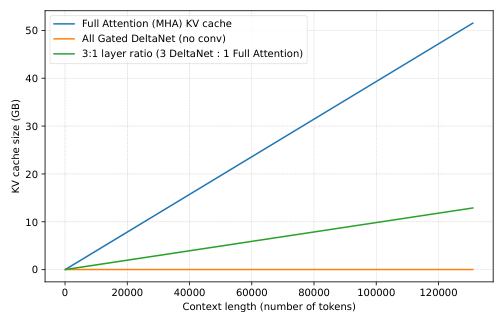

In [8]:
import fitz  # PyMuPDF
from PIL import Image
import io

# Open the PDF
pdf_path = "/kaggle/working/LLMs-from-scratch/ch04/08_deltanet/deltanet_memory_plot.pdf"
doc = fitz.open(pdf_path)

# Loop through pages, convert them to images, and display
for page_num in range(len(doc)):
    page = doc.load_page(page_num)
    pix = page.get_pixmap()
    
    # Convert raw pixmap bytes to an image data format
    img_data = pix.tobytes("png")
    img = Image.open(io.BytesIO(img_data))
    
    # Display it in the notebook output
    display(img)
